# Exploratory Data Analysis

Feature set: 'data/processed/features.csv' — one row per MIDI file, 27 numeric
features + filename (id) + composer (label).

Goal of this notebook is to decide what is actually model-ready:
class balance, missing/degenerate columns, feature distributions & scale,
and collinearity so we can prune redundant features and choose scaling
before training.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("../data/processed/features.csv")
print(df.shape)
df.head()

(1628, 29)


,n_notes,total_duration,note_density,n_instruments,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,dur_mean,...,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,filename,composer
0,180,29.999992,6.000002,4,62.911111,8.130388,43,76,33,0.621212,...,0.155556,0.066667,0.016667,0.094444,0.044444,0.205556,0.022222,0.111111,042100b_.mid,bach
1,171,25.000000,6.840000,4,58.333333,7.713435,41,72,31,0.526316,...,0.111111,0.181287,0.005848,0.128655,0.000000,0.116959,0.093567,0.029240,043100b_.mid,bach
2,181,22.500000,8.044444,4,58.790055,8.654837,41,72,31,0.455801,...,0.016575,0.066298,0.049724,0.198895,0.000000,0.132597,0.171271,0.005525,027400b_.mid,bach
3,977,166.000000,5.885542,2,67.425793,13.362625,32,87,55,0.317746,...,0.027636,0.107472,0.039918,0.165814,0.088025,0.036847,0.092119,0.045036,Bwv0997 Partita for Lute 1mov.mid,bach
4,5450,220.328557,24.735786,8,64.809908,10.371159,36,86,50,0.281752,...,0.125872,0.111927,0.013211,0.169908,0.020550,0.123303,0.039266,0.089174,Bwv1066 Orchestral Suite n1 6mov.mid,bach


## 1. Columns, dtypes, missing values

In [19]:
ID_COL, LABEL_COL = "filename", "composer"
feature_cols = [c for c in df.columns if c not in (ID_COL, LABEL_COL)]

df[feature_cols].info()

print("\nmissing values per column:")
missing = df.isna().sum()
print(missing[missing > 0] if missing.any() else "none")

<class 'pandas.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   n_notes         1628 non-null   int64  
 1   total_duration  1628 non-null   float64
 2   note_density    1628 non-null   float64
 3   n_instruments   1628 non-null   int64  
 4   pitch_mean      1628 non-null   float64
 5   pitch_std       1628 non-null   float64
 6   pitch_min       1628 non-null   int64  
 7   pitch_max       1628 non-null   int64  
 8   pitch_range     1628 non-null   int64  
 9   dur_mean        1628 non-null   float64
 10  dur_std         1628 non-null   float64
 11  vel_mean        1628 non-null   float64
 12  vel_std         1628 non-null   float64
 13  tempo           1628 non-null   float64
 14  polyphony_mean  1628 non-null   float64
 15  pc_0            1628 non-null   float64
 16  pc_1            1628 non-null   float64
 17  pc_2            1628 non-null   float64
 18 

Our data has 1628 rows and 27 columns. Data types are int64 and float64, and there are no missing values.

## 2. Class balance

How many samples per composer? Imbalance drives metric choice and whether we stratify the train/test split.

composer
bach         1024
mozart        256
beethoven     212
chopin        136
Name: count, dtype: int64

proportion:
composer
bach         0.629
mozart       0.157
beethoven    0.130
chopin       0.084
Name: count, dtype: float64


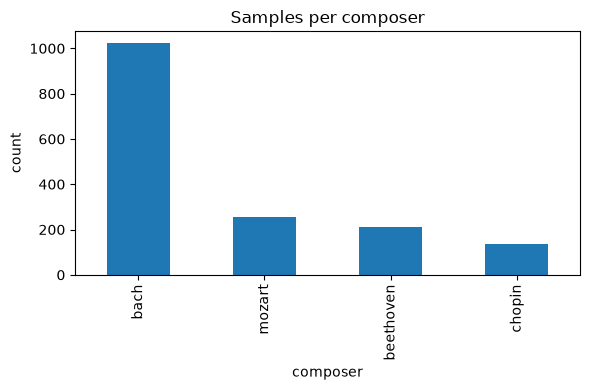

In [25]:
counts = df[LABEL_COL].value_counts()
print(counts)
print("\nproportion:")
print((counts / len(df)).round(3))

ax = counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Samples per composer")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

**There is an imbalace** If one composer dominates, accuracy will be misleading. We will evaluate with
macro-F1 / balanced accuracy, use stratify=y on the split, and consider
class weights or resampling.

## 3. Degenerate columns (constant / near-constant)

A feature with one value (or almost one) carries no signal and should be dropped.

In [8]:
nun = df[feature_cols].nunique().sort_values()
constant = nun[nun <= 1].index.tolist()
print("constant columns:", constant or "none")

# near-constant: one value covers >99% of rows
near_const = []
for c in feature_cols:
    top_frac = df[c].value_counts(normalize=True).iloc[0]
    if top_frac > 0.99:
        near_const.append((c, round(top_frac, 4)))
print("near-constant (>99% one value):", near_const or "none")

nun.head(10)

constant columns: none
near-constant (>99% one value): none


n_instruments       30
pitch_max           38
pitch_min           41
pitch_range         59
vel_std            847
vel_mean           860
n_notes           1245
total_duration    1283
pc_3              1385
pc_8              1390
dtype: int64

No constant or near-constant columns. Every feature varies across the dataset, so none can be dropped on degeneracy grounds. Note 'vel_mean', 'vel_std' are not flat despite looking constant in the first few rows.

## 4. Summary statistics & feature scale

Features live on very different scales (e.g. 'tempo' in the hundreds vs 'pc_*' in [0,1]). This matters for any gradient based model.

In [9]:
desc = df[feature_cols].describe().T[["mean", "std", "min", "max"]]
desc["range"] = desc["max"] - desc["min"]
desc.sort_values("range", ascending=False)

,mean,std,min,max,range
n_notes,3118.531941,4784.975083,83.000000,46897.000000,46814.000000
total_duration,245.948097,318.735113,17.500000,5209.310787,5191.810787
tempo,186.038134,38.488612,52.360524,295.820789,243.460265
vel_mean,83.582276,18.638750,30.812865,127.000000,96.187135
pitch_range,48.919533,11.977762,21.000000,84.000000,63.000000
pitch_min,35.259214,6.372604,9.000000,62.000000,53.000000
note_density,10.875353,7.435646,0.595751,51.308206,50.712455
pitch_max,84.178747,6.999560,66.000000,107.000000,41.000000
vel_std,6.845817,8.349205,0.000000,40.063986,40.063986
n_instruments,5.281327,4.507533,1.000000,40.000000,39.000000


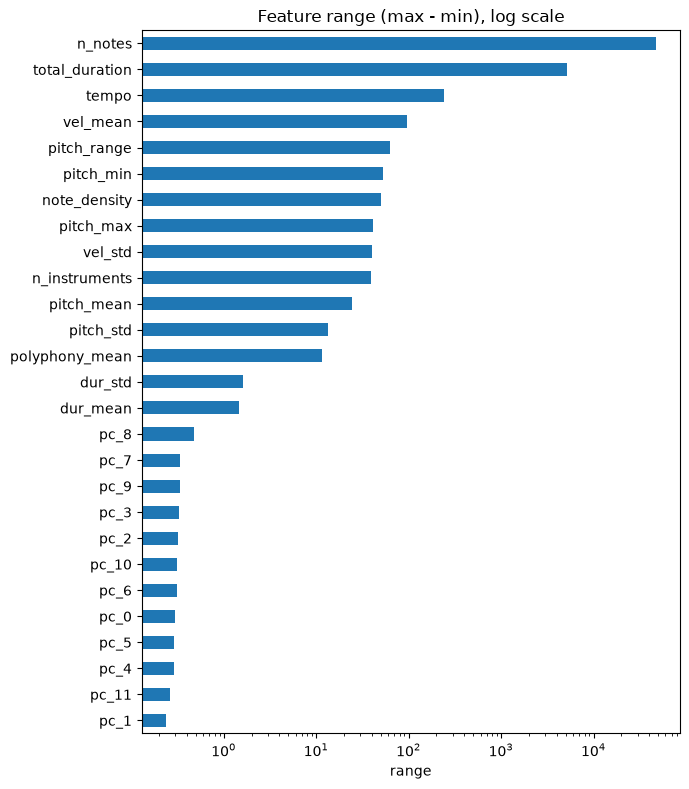

In [10]:
# Visualize scale spread across features (log axis)
ranges = (df[feature_cols].max() - df[feature_cols].min()).sort_values()
ax = ranges.plot(kind="barh", figsize=(7, 8))
ax.set_xscale("log")
ax.set_title("Feature range (max - min), log scale")
ax.set_xlabel("range")
plt.tight_layout()
plt.show()

Wide spread confirms we need scaling (StandardScaler / MinMax) 

## 5. Distributions

Histograms per feature to spot skew, multimodality, and outliers.

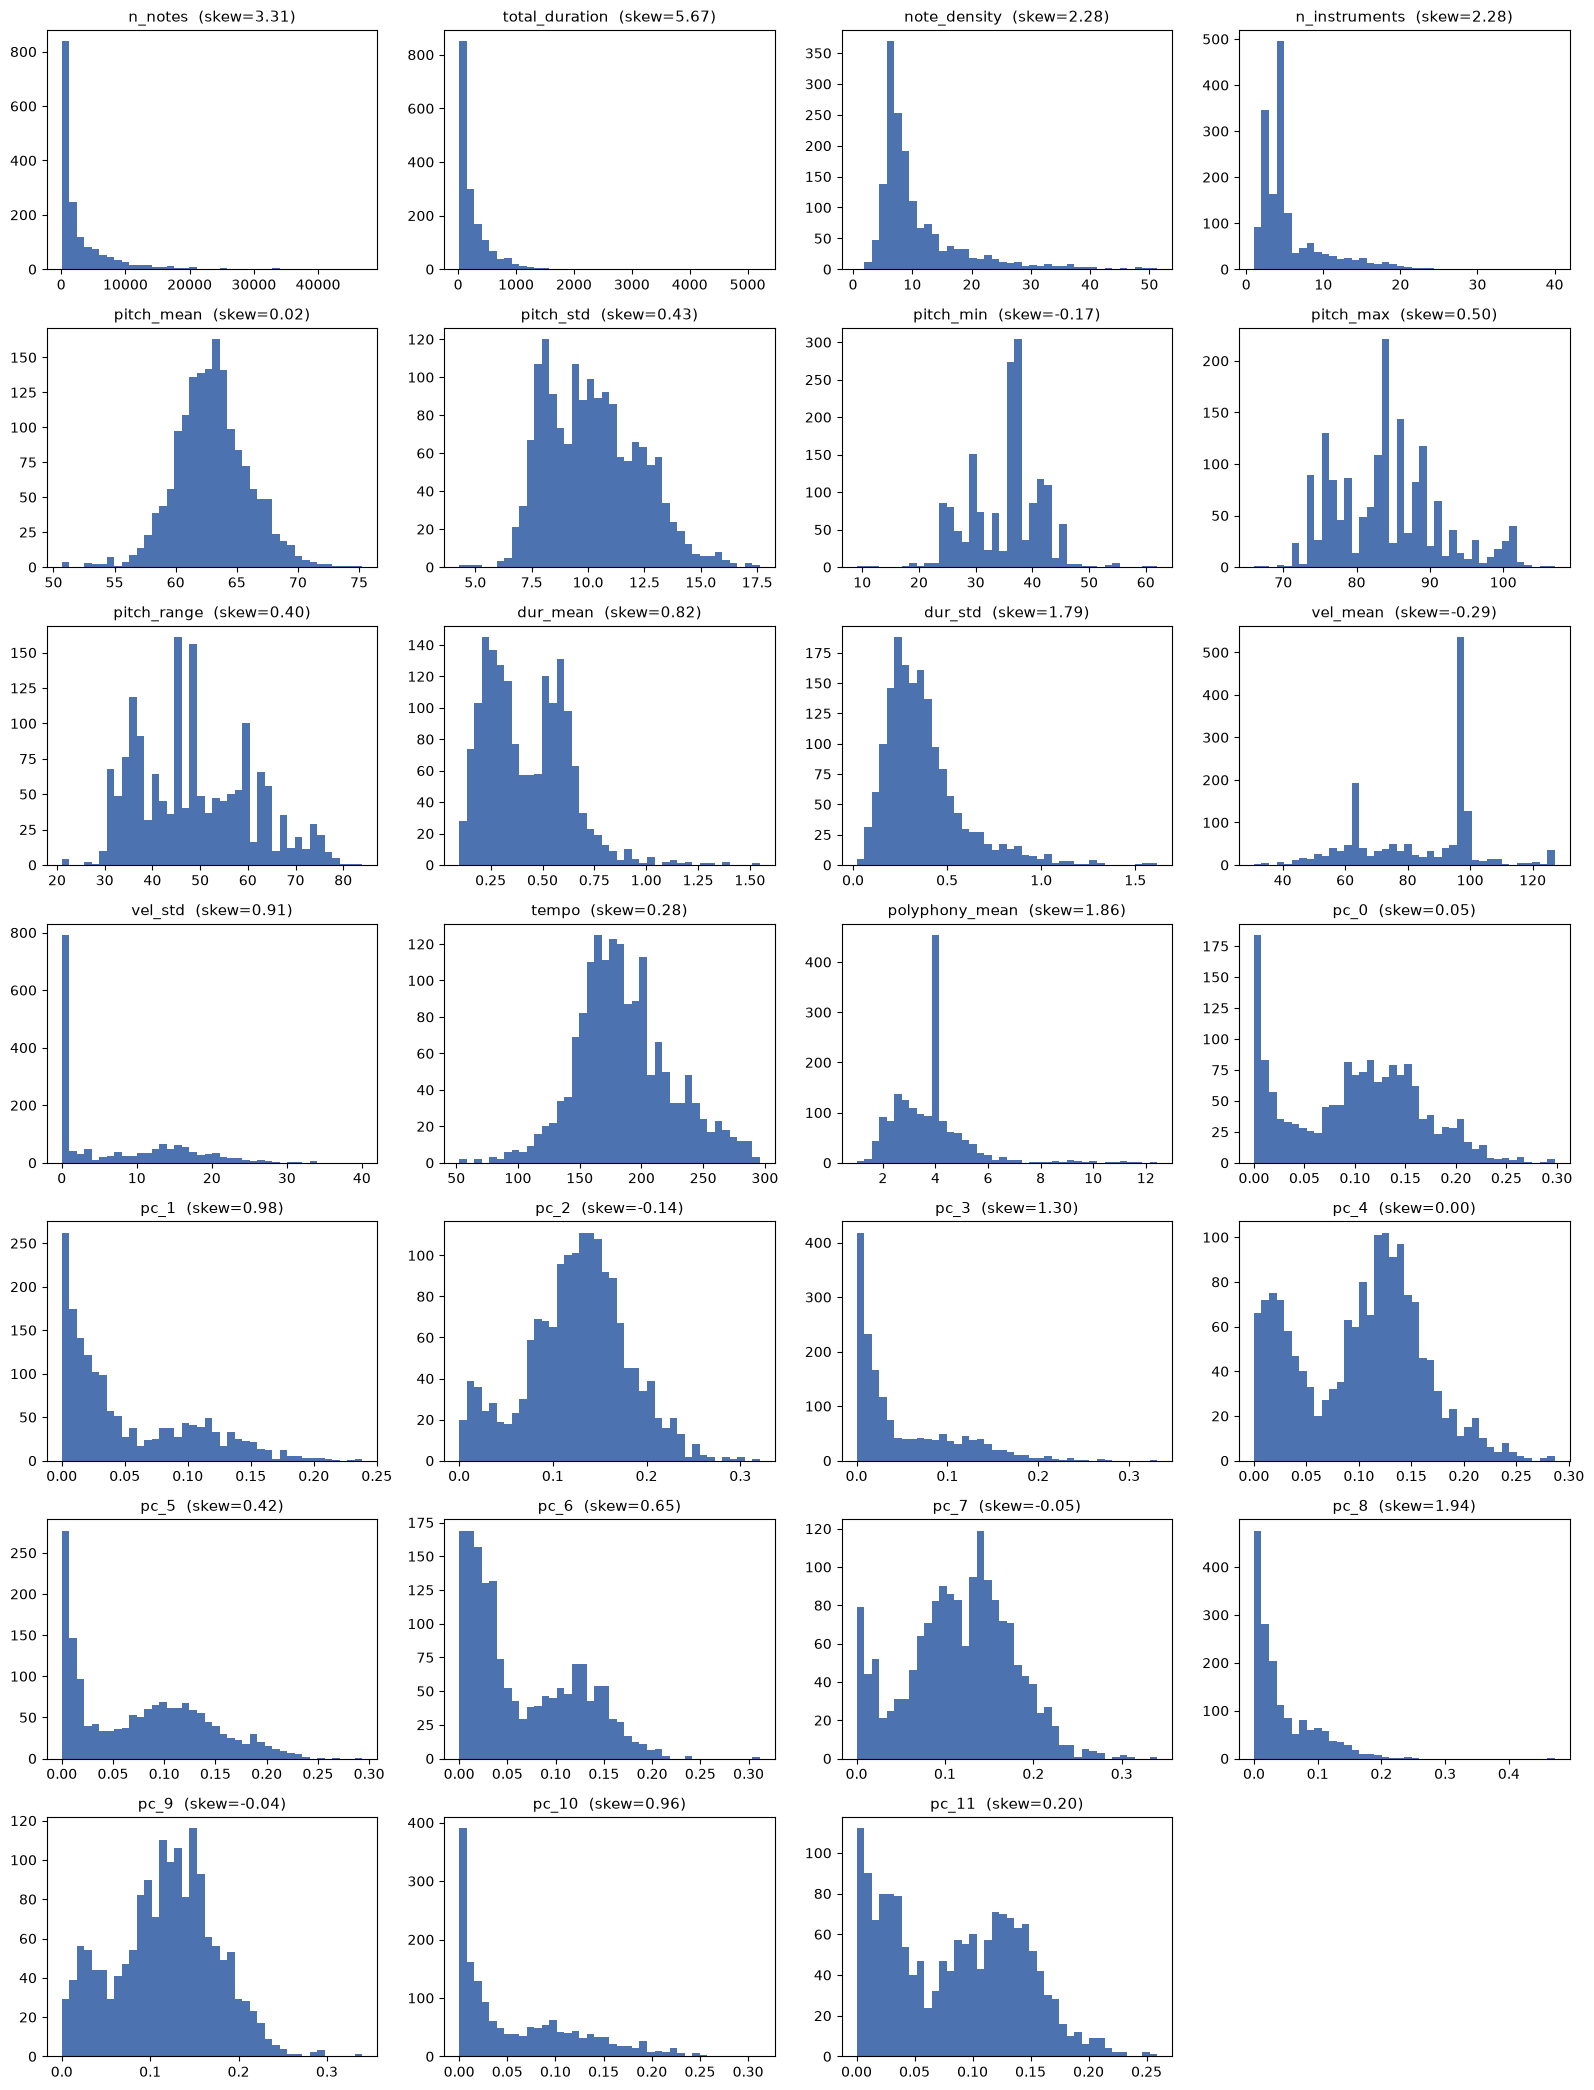

In [27]:
n = len(feature_cols)
ncol = 4
nrow = int(np.ceil(n / ncol))
skew = df[feature_cols].skew()
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
for ax, c in zip(axes.ravel(), feature_cols):
    ax.hist(df[c], bins=40, color="#4c72b0")
    ax.set_title(f"{c}  (skew={skew[c]:.2f})", fontsize=11)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

The histograms show a few distinct shapes, each calling for different handling before scaling:

- **Strong right skew, strictly positive** — 'total_duration' (skew 5.7), 'n_notes' (3.3), 'note_density' (2.3), 'dur_std' (1.8), 'dur_mean' (0.8). Good candidates for log1p to compress the long tails.
- **Mild right skew, count-like** — 'n_instruments' (2.3), 'polyphony_mean' (1.9). 'sqrt' is a gentler fit than log for small-integer counts.
- **Zero-inflated (not skewed)** — 'vel_std' has ~47% of pieces at exactly 0 (flat-velocity MIDI). No power transform fixes a spike at zero. Better to add a binary 'has_vel_var' flag alongside the value.
- **Bounded proportions [0,1]** — the 'pc_*' bins are near symmetric and contain real zeros, so lets leave their shape alone (logit would break on the zeros); scale only.
- **Already ~symmetric** (|skew| < 0.5) — 'pitch_mean', 'pitch_std', 'pitch_min/max', 'tempo', 'vel_mean'. No transform needed.

Rather than hand-pick log vs sqrt per feature, PowerTransformer(method="yeo-johnson", standardize=True) can auto-select the power per feature (and handles zeros), applied to the skewed continuous group; plain StandardScaler for the symmetric features and 'pc_*' bins. All transforms must be fit on the training split only. They belong in the modeling pipeline, not baked into the feature CSV.

## 6. Correlation & collinearity

Correlated features are redundant. For our LSTM/CNN this won't break training, but on only 1,628 rows the redundancy still wastes model capacity, invites overfitting, and makes the loss surface more textured (slower, zig-zaggy convergence that Adam/normalization only partly offset).

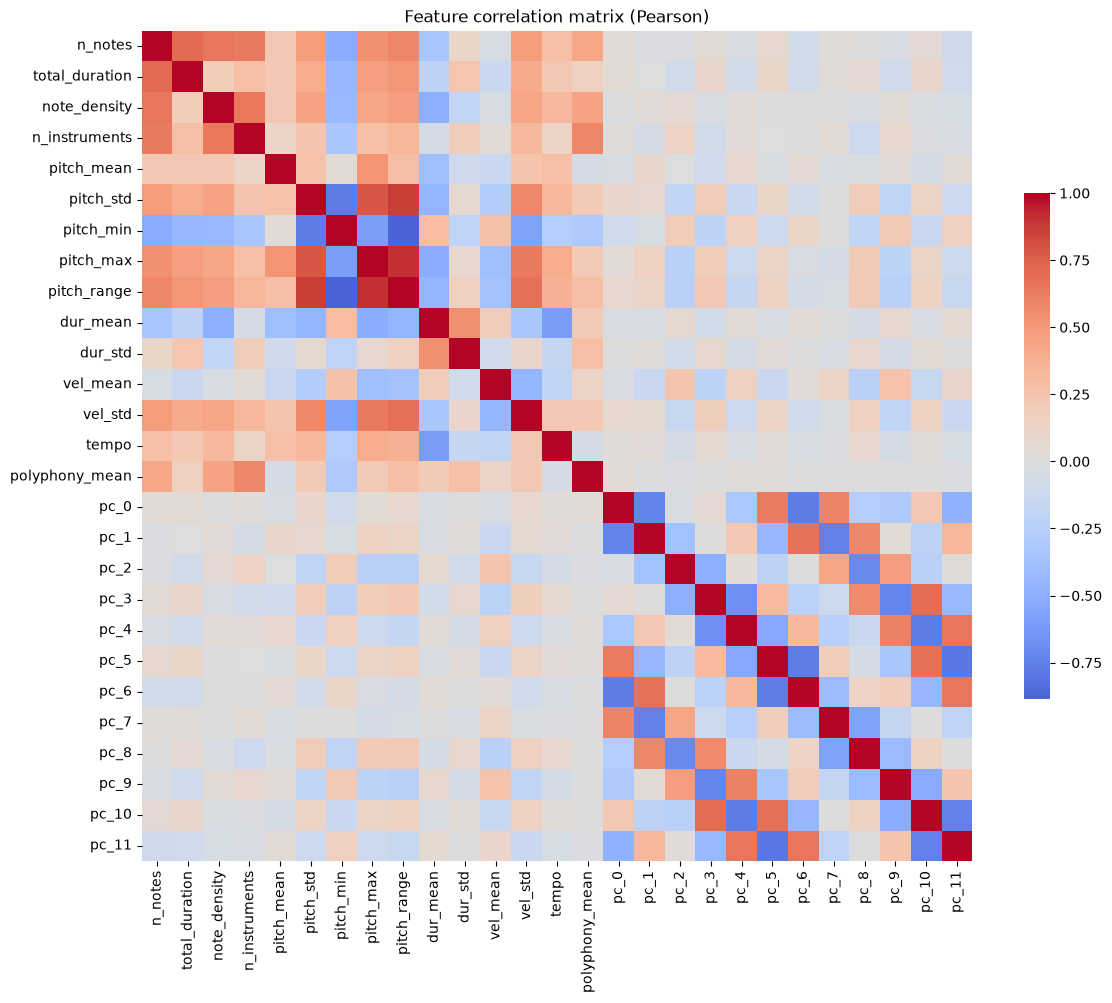

In [12]:
corr = df[feature_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

In [13]:
# Flag highly correlated pairs
THRESH = 0.85
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr"})
)
high = pairs[pairs["corr"].abs() >= THRESH].sort_values("corr", key=abs, ascending=False)
print(f"pairs with |corr| >= {THRESH}:")
high

pairs with |corr| >= 0.85:


,feat_a,feat_b,corr
197,pitch_max,pitch_range,0.905607
170,pitch_min,pitch_range,-0.884867
143,pitch_std,pitch_range,0.869738


### Known derived features to watch

- 'pitch_rang' = 'pitch_max' - 'pitch_min' — linearly dependent; drop one of the three.
- 'note_density' is derived from 'n_notes' / 'total_duration'.
- 'pitch_mean' overlaps with the 12 'pc_*' pitch-class bins.

Confirm these against the flagged pairs above before deciding what to drop.

In [ ]:
# Variance Inflation Factor (VIF) — multicollinearity, not just pairwise

def vif_table(X):
    X = X.copy()
    X = (X - X.mean()) / X.std(ddof=0)  # standardize for comparability
    vifs = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        vifs[c] = np.inf if r2 >= 1 else 1.0 / (1.0 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

vif = vif_table(df[feature_cols])
print("VIF > 10 indicates problematic multicollinearity:")
vif

VIF > 10 indicates problematic multicollinearity:


pc_11                  inf
pc_0                   inf
pc_10                  inf
pc_9                   inf
pc_8                   inf
pc_7                   inf
pitch_min              inf
pitch_max              inf
pitch_range            inf
pc_6                   inf
pc_5                   inf
pc_4                   inf
pc_3                   inf
pc_2                   inf
pc_1                   inf
n_notes           5.543439
dur_mean          4.942099
pitch_std         4.442193
note_density      4.315618
total_duration    3.239464
n_instruments     2.826281
dur_std           2.301782
vel_std           2.293761
polyphony_mean    2.274136
pitch_mean        2.186101
tempo             1.767247
vel_mean          1.596990
dtype: float64

Two exact dependencies show up as infinite VIF. 'pitch_min'/'pitch_max'/'pitch_range' are collinear because 'pitch_range' = 'pitch_max' - 'pitch_min' (also visible in the correlation pairs above), and all twelve 'pc_*'  bins are collinear because they sum to 1.0. Dropping 'pitch_range' and one 'pc' bin will remove both, after which no feature has infinite VIF and the rest sit at a moderate < ~6. The remaining correlation is mild and fine for the nets, so no further pruning is needed.

## 7. Do features separate the composers?

Standardized per-class means: which features actually differ across composers (i.e. carry signal for classification)?

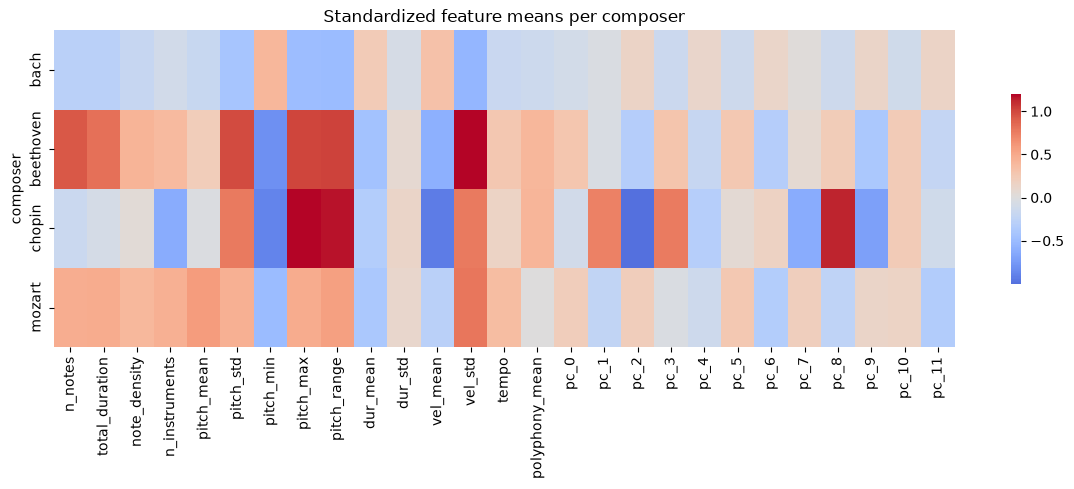

vel_std           0.765073
pitch_range       0.757013
pitch_max         0.756280
pc_8              0.622481
pitch_std         0.616806
pitch_min         0.594706
n_notes           0.568886
pc_2              0.558940
vel_mean          0.533916
total_duration    0.508300
n_instruments     0.501891
pc_1              0.428152
pc_9              0.415882
pc_3              0.410465
pc_7              0.369283
dtype: float64

In [15]:
z = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std(ddof=0)
z[LABEL_COL] = df[LABEL_COL]
class_means = z.groupby(LABEL_COL)[feature_cols].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(class_means, cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.6})
plt.title("Standardized feature means per composer")
plt.tight_layout()
plt.show()

# Rank features by how much their class means spread (proxy for discriminative power)
class_means.std().sort_values(ascending=False).head(15)

The features do carry class signal, which means the problem is learnable from this data. The strongest separators are 'vel_std', 'pitch_range'/'pitch_max'/'pitch_std', 'pc_8', and the size features ('n_notes', 'total_duration').

**Bach is the easy class:** distinctly low 'vel_std', narrow pitch range, high 'pitch_min' — it sits opposite the other three on almost every top feature. Beethoven, Chopin, and Mozart overlap more (all positive on 'vel_std' and 'pitch_range'), so I'd expect most confusion among those three; Chopin is the most separable of them thanks to a high 'pc_8' and the widest pitch range.

Note pitch_range ranks high here but we drop it for collinearity with no signal lost, since 'pitch_max'/'pitch_min' (also top-ranked) carry the same information.

## Summary

**Data:** 1,628 pieces × 27 features, 4 composers. No missing or degenerate columns. 

**Remove** 'pitch_range' and 'pc_11', both exact dependencies;

**Modeling Choices**
- **Imbalance** (bach 63%) — stratify the split, use class weights, judge by macro-F1 not accuracy.
- **Scale + skew** — must scale; several features are heavily right-skewed ('total_duration', 'n_notes', …). Fit a PowerTransformer(yeo-johnson) + scaler on train only, inside a Pipeline
